# Regresión y regularización con `scikit-learn`

In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)

# 1. Regresión lineal

La regresión lineal es una técnica de aprendizaje automático supervisado que se utiliza para predecir una variable continua, llamada variable dependiente o variable objetivo, a partir de una o más variables independientes, también llamadas características o *features*.

A diferencia de la clasificación, donde la salida pertenece a una clase discreta, en regresión la salida pertenece a una escala numérica continua. Por ejemplo, puede utilizarse para estimar el precio de una vivienda, el consumo energético de un edificio, la concentración de una sustancia o la respuesta esperada de un sensor.

## 1.1 Regresión lineal simple

En la regresión lineal simple se modela la relación entre una única variable de entrada $x$ y una salida continua $y$. El modelo se escribe como:

$$
\hat{y}=w_0+w_1x
$$

donde $\hat{y}$ es la predicción del modelo, $w_0$ es la ordenada al origen o intercepto y $w_1$ es la pendiente de la recta. El objetivo del entrenamiento es encontrar los valores de $w_0$ y $w_1$ que permitan que la recta se ajuste lo mejor posible a los datos observados.

Intuitivamente, entrenar una regresión lineal consiste en encontrar la recta que minimiza la diferencia entre los valores reales y las predicciones del modelo.

## 1.2 Regresión lineal con múltiples características

La misma idea se extiende a problemas con $M$ características. Para una instancia $i$:

$$
\hat{y}^{(i)}
=
w_0+w_1x_1^{(i)}+w_2x_2^{(i)}+\cdots+w_Mx_M^{(i)}
$$

Si tenemos $N$ ejemplos y agregamos una primera columna de unos para representar el intercepto, podemos organizar los datos en una matriz de diseño:

$$
\mathbf{X}=
\begin{bmatrix}
1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_M^{(1)}\\
1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_M^{(2)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_1^{(N)} & x_2^{(N)} & \cdots & x_M^{(N)}
\end{bmatrix},
\qquad
\mathbf{W}=
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_M
\end{bmatrix}
$$

Entonces todas las predicciones se escriben de forma compacta como:

$$
\hat{\mathbf{y}}=\mathbf{X}\mathbf{W}
$$

Esta formulación es importante porque permite describir con una única expresión tanto la regresión lineal con varias características como, más adelante, la regresión polinomial. Lo que cambiará será la matriz de características, no la estructura lineal del modelo respecto de sus parámetros.

## 1.3 ¿Qué significa ajustar el modelo?

El ajuste busca valores de los parámetros que minimicen el error cuadrático entre las predicciones y los valores reales. Puede pensarse en términos de:

$$
\text{MSE}=
\frac{1}{N}
\sum_{i=1}^{N}
\left(y^{(i)}-\hat y^{(i)}\right)^2.
$$

En esta notebook no implementaremos el procedimiento de estimación de los parámetros. Utilizaremos `LinearRegression` de `scikit-learn`.

## 1.4 Aplicación con `data_1.txt`

El archivo `data_1.txt` contiene un conjunto sencillo para regresión lineal. La primera columna corresponde a la variable independiente y la segunda a la variable objetivo.

Los datos representan el precio de una vivienda en función de la población de una ciudad. La población está expresada en unidades de 10.000 habitantes y el precio en unidades de 10.000 dólares.

### Actividad 1

1. Cargue los datos y represéntelos mediante un diagrama de dispersión.
2. Ajuste un modelo `LinearRegression`.
3. Obtenga y muestre el término independiente y la pendiente.
4. Obtenga y muestre los parámetros del modelo.
5. Grafique la recta ajustada sobre los datos.
6. Interprete el signo y la magnitud de la pendiente.


Text(0.5, 1.0, 'precio - población')

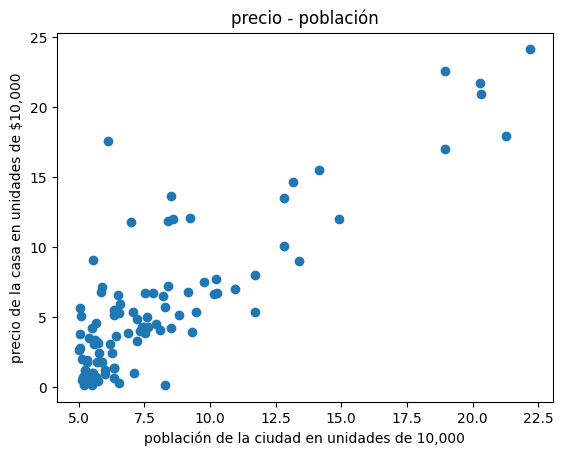

In [45]:
df = pd.read_csv('data_1.txt', header = None)
plt.scatter(df[0], df[1])
plt.xlabel("población de la ciudad en unidades de 10,000")
plt.ylabel("precio de la casa en unidades de $10,000")
plt.title("precio - población")

In [46]:
X = df[[0]]
y = df[1]

reg_lineal = LinearRegression()
reg_lineal.fit(X, y)

w_0 = reg_lineal.intercept_
w_1 = reg_lineal.coef_[0]

print("--- PARÁMETROS DEL MODELO ---")
print(f"Término independiente (w_0): {w_0:.4f}")
print(f"Pendiente (w_1): {w_1:.4f}")
print(f"Ecuación estimada: y = {w_0:.4f} + {w_1:.4f} * X\n")

--- PARÁMETROS DEL MODELO ---
Término independiente (w_0): -3.5810
Pendiente (w_1): 1.1698
Ecuación estimada: y = -3.5810 + 1.1698 * X



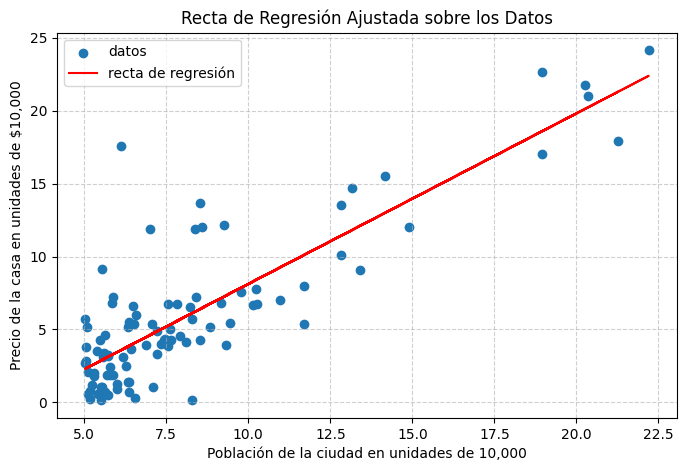

In [47]:
y_pred = reg_lineal.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(df[0], df[1], label="datos")
plt.plot(df[0], y_pred, color="red", label="recta de regresión")

plt.xlabel("Población de la ciudad en unidades de 10,000")
plt.ylabel("Precio de la casa en unidades de $10,000")
plt.title("Recta de Regresión Ajustada sobre los Datos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

- interpretacion:
la pendiente positiva en la media nos indica que hay una relacion directa entre el precio de las viviendas y la población, aumentando el precio de las viviendas a medida que la población aumenta.
El valor de la pendiente es de 1,1930 ésto nos dice que por cada 10.000 habitantes el precio de la vivienda aumenta aproximadamente $11.930.

# 2. Desempeño del modelo de regresión

Después de ajustar un modelo necesitamos evaluar cuánto se equivoca. En regresión utilizaremos tres métricas complementarias.

## 2.1 Error Cuadrático Medio (MSE)

$$
\text{MSE}=
\frac{1}{N}
\sum_{i=1}^{N}
\left(y^{(i)}-\hat y^{(i)}\right)^2
$$

El MSE es siempre mayor o igual que cero. Penaliza con mayor fuerza los errores grandes y queda expresado en unidades cuadradas de la variable objetivo.

## 2.2 Raíz del Error Cuadrático Medio (RMSE)

$$
\text{RMSE}=\sqrt{\text{MSE}}
$$

El RMSE vuelve a expresarse en las mismas unidades de la variable objetivo, por lo que suele ser más intuitivo para interpretar la magnitud del error.

## 2.3 Coeficiente de determinación $R^2$

El coeficiente de determinación $R^2$ evalúa el desempeño del modelo comparando su error con el de un predictor de referencia muy simple: un modelo que siempre predice la media de los valores reales de la variable objetivo.

$$
R^2=1-\frac{\sum_{i=1}^{N}\left(y^{(i)}-\hat{y}^{(i)}\right)^2}{\sum_{i=1}^{N}\left(y^{(i)}-\mu_y\right)^2}
$$

donde $\mu_y$ es la media de los valores reales de $y$.

El numerador representa el error cuadrático cometido por el modelo. El denominador representa el error que cometeríamos si ignoráramos las variables de entrada y predijéramos siempre $$\mu_y$$. Por eso, $R^2$ compara el error del modelo aprendido contra el error del predictor basado en la media.

La interpretación usual es:

- $R^2=1$: el modelo predice perfectamente los valores evaluados.
- $0<R^2<1$: el modelo predice mejor que utilizar siempre la media.
- $R^2=0$: el modelo tiene el mismo desempeño que predecir siempre la media.
- $R^2<0$: el modelo predice peor que utilizar siempre la media.

Por ejemplo, $$R^2=0.8$$ significa que el error cuadrático del modelo representa solamente el 20% del error que tendría el predictor basado en la media.

Es importante no analizar el MSE de manera aislada. Un mismo valor de MSE puede ser aceptable o inaceptable dependiendo de la escala de la variable objetivo. Por eso conviene comparar MSE, RMSE, rango de los valores reales y $R^2$.

## 2.4 Entrenamiento y prueba con `data_2.csv`

Para analizar desempeño sobre datos no utilizados durante el ajuste, dividiremos `data_2.csv` en un conjunto de entrenamiento y otro de prueba.

### Actividad 2

1. Separe los datos en entrenamiento y prueba.
2. Ajuste `LinearRegression` usando únicamente el conjunto de entrenamiento.
3. Calcule MSE, RMSE y $R^2$ en ambos conjuntos.
4. Compare los errores y discuta si existe evidencia de un problema de generalización.

In [48]:
df2 = pd.read_csv('data_2.csv')
X2 = df2[['X']]
y2 = df2['y']

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
print(f"N de datos de entrenamiento: {len(X_train)}")
print(f"N de datos de prueba: {len(X_test)}")

N de datos de entrenamiento: 400000
N de datos de prueba: 100000


In [49]:
model2 = LinearRegression()
model2.fit(X_train, y_train)


LinearRegression()

In [50]:
y_train_pred = model2.predict(X_train)
y_test_pred = model2.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = root_mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("- - - - - RESULTADOS - - - - -")
print(f"Entrenamiento (Train):")
print(f"  MSE:  {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  R2:   {r2_train:.4f}")
print("- - - - - - - - - - - - - - -")
print(f"Prueba (Test):")
print(f"  MSE:  {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R2:   {r2_test:.4f}")

- - - - - RESULTADOS - - - - -
Entrenamiento (Train):
  MSE:  4.3114
  RMSE: 2.0764
  R2:   0.9154
- - - - - - - - - - - - - - -
Prueba (Test):
  MSE:  4.3080
  RMSE: 2.0756
  R2:   0.9151


- Conclusion:
El modelo tiene un buen desempeñp, ya que el error del modelo test es casi identico al del modelo de train.
Generaliza correctamente sobre datos nuevos, logrando predecir con la misma precision que en la fase de entrenamiento.

# 3. Linealidad, no linealidad y regresión polinomial

Antes de introducir la regresión polinomial es importante distinguir **dos sentidos diferentes de linealidad**.

Un modelo puede ser lineal o no lineal respecto de las **variables de entrada**, pero también puede ser lineal o no lineal respecto de sus **parámetros**. Para la regresión lineal, la segunda distinción es la fundamental.

Por ejemplo:

$$
\hat y=w_0+w_1x
$$

es lineal respecto de $x$ y también respecto de los parámetros $w_0,w_1$.

En cambio:

$$
\hat y=w_0+w_1x+w_2x^2
$$

es no lineal respecto de $x$, porque incluye $x^2$, pero sigue siendo lineal respecto de los parámetros: $w_0,w_1,w_2$ aparecen solamente multiplicando características y sumándose.

Un modelo como:

$$
\hat y=a\,e^{bx}
$$

es no lineal respecto de sus parámetros, porque el parámetro $b$ aparece dentro de una función exponencial. En estos casos ya no podemos representar el modelo simplemente como $\hat{\mathbf y}=XW$ usando una matriz de características fija, y normalmente se necesitan métodos de optimización no lineal.

Esta notebook se concentrará en modelos **lineales en los parámetros**, incluyendo la regresión polinomial.

## 3.1 Regresión polinomial con `scikit-learn`

La regresión lineal simple ajusta una recta. Sin embargo, muchos problemas reales presentan relaciones no lineales entre las variables. En esos casos, una recta puede ser demasiado limitada.

Una forma de extender el modelo es transformar la variable de entrada agregando potencias de $x$. Por ejemplo, un modelo polinomial de grado 3 se escribe como:

$$
\hat{y}=w_0+w_1x+w_2x^2+w_3x^3
$$

Aunque la relación entre $x$ e $y$ ya no sea una recta, el modelo sigue siendo **lineal respecto de los parámetros**. Por eso, la regresión polinomial puede entenderse como una regresión lineal aplicada sobre una nueva matriz de características:

$$
\mathbf{X}_{poly}=\begin{bmatrix}
1 & x_1 & x_1^2 & \cdots & x_1^d \\
1 & x_2 & x_2^2 & \cdots & x_2^d \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_N & x_N^2 & \cdots & x_N^d
\end{bmatrix}
$$

El modelo queda:

$$
\hat{\mathbf{y}}=\mathbf{X}_{poly}\mathbf{W}
$$

La elección del grado controla la flexibilidad del modelo. Un grado muy bajo puede no capturar la estructura de los datos y uno demasiado alto puede adaptarse excesivamente al conjunto de entrenamiento. Más adelante analizaremos este fenómeno comparando desempeño de entrenamiento y validación.

Además, cuando se agregan potencias altas de $x$, las escalas de las características pueden cambiar mucho. Por ejemplo, si $x=20$, entonces $x^5=3.200.000$. Esto puede dificultar los cálculos numéricos realizados por el algoritmo. Por esa razón, cuando se usa `scikit-learn`, es habitual combinar `PolynomialFeatures` con `StandardScaler` dentro de un `Pipeline`.

La regresión polinomial transforma una variable $x$ en nuevas características:

$$
x,\;x^2,\;x^3,\ldots,x^d
$$

y luego ajusta una regresión lineal sobre esas características.

Con `scikit-learn`, este flujo puede implementarse mediante:

1. `PolynomialFeatures` para generar las potencias;
2. `StandardScaler` para escalar las características;
3. `LinearRegression` para ajustar el modelo.

## 3.2 Aplicación con `data_3.csv`

### Actividad 3

1. Represente los datos.
2. Ajuste modelos polinomiales de grados 1, 3, 7 y 13.
3. Grafique las curvas sobre el mismo conjunto de datos.
4. Compare cómo cambia la forma de la función al aumentar el grado.
5. ¿Puede decidir cuál generaliza mejor mirando únicamente este gráfico? Justifique.

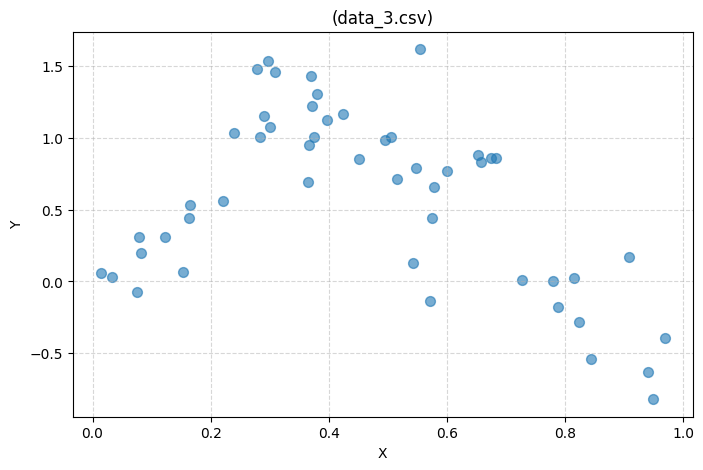

In [51]:
df3 = pd.read_csv('data_3.csv')
X3 = df3[['X']]
y3 = df3['Y']

plt.figure(figsize=(8, 5))
plt.scatter(X3, y3, alpha=0.6, s=50)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('(data_3.csv)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [52]:
grados = [1, 3, 7, 13]
modelos = {}

for grado in grados:
    pipeline = Pipeline([
        ('poly_features', PolynomialFeatures(degree=grado, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linear_regression', LinearRegression())
    ])

    pipeline.fit(X3, y3)

    modelos[grado] = pipeline

    print(f"Modelo de grado {grado} ajustado")

Modelo de grado 1 ajustado
Modelo de grado 3 ajustado
Modelo de grado 7 ajustado
Modelo de grado 13 ajustado


In [53]:
X_linspace = np.linspace(X3.min(), X3.max(), 100).reshape(-1, 1)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


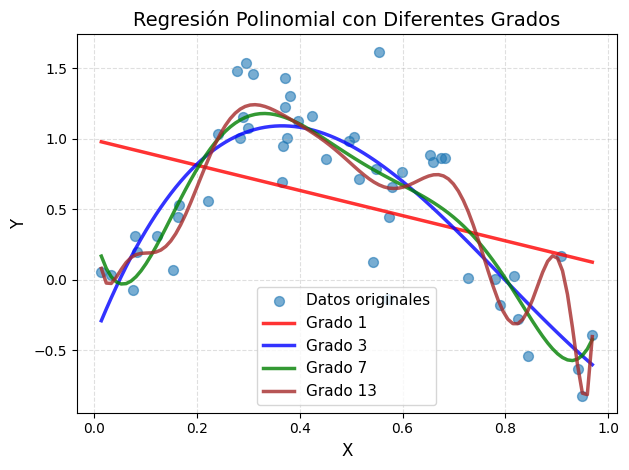

In [54]:
plt.scatter(X3, y3, alpha=0.6, s=50, label='Datos originales')

colores = ['red', 'blue', 'green', 'brown']

for i, grado in enumerate(grados):
    y_pred_linspace = modelos[grado].predict(X_linspace)
    plt.plot(X_linspace, y_pred_linspace, color=colores[i], linewidth=2.5,
             label=f'Grado {grado}', alpha=0.8)

plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Regresión Polinomial con Diferentes Grados', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

- COMPARACIÓN:
Al aumentar de grado se observa que la función se vuelve más flexible, sobreajustando el modelo, lo que lo hace excelente para los datos existentes pero perdiendo precision para predecir nuevos datos.

- ¿CUÁL GENERALIZA MEJOR?
Únicamente mirando el grafico no se puede decir cuál generaliza mejor, ya que depende de a qué conjunto de datos se aplique el modelo (cuál se adapta mejor al conjunto con el que fue entrenado el modelo).

# 4. Complejidad del modelo y generalización

A medida que aumenta el grado del polinomio, aumenta también la flexibilidad del modelo. Esto puede mejorar el ajuste sobre los datos de entrenamiento, pero no garantiza que el modelo funcione mejor sobre datos nuevos.

Dos situaciones extremas son:

- **Subajuste (*underfitting*)**: el modelo es demasiado simple para representar la estructura de los datos. Suele asociarse con un error de entrenamiento relativamente alto.
- **Sobreajuste (*overfitting*)**: el modelo se adapta demasiado a particularidades o ruido del conjunto de entrenamiento. El error de entrenamiento puede ser muy bajo mientras que el error de validación aumenta.

Esta idea se relaciona con el compromiso entre **sesgo y varianza**. Un modelo muy restrictivo suele tener mayor sesgo porque impone una forma demasiado simple. Un modelo excesivamente flexible puede tener mayor varianza porque pequeñas modificaciones en los datos de entrenamiento pueden producir cambios importantes en el modelo aprendido.

Para estudiar generalización necesitamos evaluar el modelo sobre datos que no se utilizaron para ajustar sus parámetros. En esta sección utilizaremos un conjunto de entrenamiento y otro de validación.

## 4.1 Comparación de grados con `data_7.mat`

El archivo contiene:

- `X`, `y`: datos de entrenamiento;
- `Xval`, `yval`: datos de validación.

### Actividad 4

Ajuste modelos polinomiales sin regularización para diferentes grados (1, 3, 5, 7, 9, 11, 13, 15). Para cada grado:

1. calcule MSE y $R^2$ sobre entrenamiento;
2. calcule MSE y $R^2$ sobre validación;
3. grafique MSE de entrenamiento y validación en función del grado;
4. identifique evidencia de subajuste, buen compromiso y sobreajuste.

Si dos modelos presentan desempeños de validación muy similares, ¿qué otros criterios podrían utilizarse para preferir uno sobre otro?

In [55]:
data_mat = scipy.io.loadmat('data_7.mat')

X_train = data_mat['X']
y_train = data_mat['y'].ravel()
X_val = data_mat['Xval']
y_val = data_mat['yval'].ravel()

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Validación: {X_val.shape[0]} muestras")

Entrenamiento: 50 muestras
Validación: 30 muestras


In [56]:
grados = [1, 3, 5, 7, 9, 11, 13, 15]

mse_train_list = []
mse_val_list = []

for grado in grados:

    poly = PolynomialFeatures(degree=grado, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled = scaler.transform(X_val_poly)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)

    mse_train_list.append(mse_train)
    mse_val_list.append(mse_val)

    print(f"Grado {grado:2d} | MSE_train: {mse_train:.4f} | MSE_val: {mse_val:.4f}")

Grado  1 | MSE_train: 62.0071 | MSE_val: 25.8297
Grado  3 | MSE_train: 14.2834 | MSE_val: 9.1812
Grado  5 | MSE_train: 13.6581 | MSE_val: 6.3040
Grado  7 | MSE_train: 4.7258 | MSE_val: 71.6069
Grado  9 | MSE_train: 2.1349 | MSE_val: 29.0968
Grado 11 | MSE_train: 1.7527 | MSE_val: 23.0155
Grado 13 | MSE_train: 1.6515 | MSE_val: 167.2563
Grado 15 | MSE_train: 1.5737 | MSE_val: 256.3906


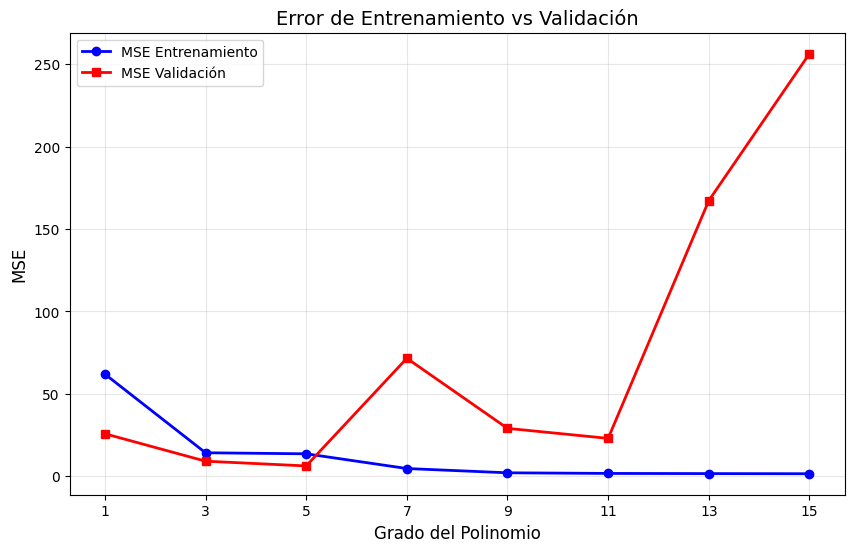

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(grados, mse_train_list, 'o-', linewidth=2, label='MSE Entrenamiento', color='blue')
plt.plot(grados, mse_val_list, 's-', linewidth=2, label='MSE Validación', color='red')

plt.xlabel('Grado del Polinomio', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Error de Entrenamiento vs Validación', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(grados)
plt.show()

# 5. Regresión polinomial con regularización

La regularización modifica la función de costo agregando una penalización sobre los coeficientes del modelo. Su objetivo es limitar soluciones excesivamente complejas y reducir la sensibilidad a los datos de entrenamiento.

En regresión polinomial esto resulta especialmente importante cuando se utilizan grados altos, porque las características transformadas permiten construir curvas muy flexibles.

## 5.1 Ridge: regularización L2

Ridge agrega una penalización proporcional al cuadrado de los coeficientes:

$$
\mathcal{L}_{L2}
=
\text{MSE}
+
\lambda\sum_{j=1}^{d}w_j^2
$$

La penalización favorece coeficientes pequeños, pero normalmente no los lleva exactamente a cero. Por eso Ridge tiende a suavizar el modelo conservando todos los términos.

## 5.2 Lasso: regularización L1

Lasso agrega una penalización proporcional al valor absoluto de los coeficientes:

$$
\mathcal{L}_{L1}
=
\text{MSE}
+
\lambda\sum_{j=1}^{d}|w_j|
$$

Esta penalización puede llevar algunos coeficientes exactamente a cero. Por eso Lasso puede actuar como mecanismo de selección de características.

## 5.3 Elastic Net

Elastic Net combina ambas penalizaciones. Conceptualmente puede escribirse como:

$$
\mathcal{L}_{EN}
=
\text{MSE}
+
\lambda
\left[
\rho\sum_{j=1}^{d}|w_j|
+
(1-\rho)\sum_{j=1}^{d}w_j^2
\right]
$$

El parámetro $\lambda$ controla la intensidad global de la regularización y $\rho$ controla cuánto pesa cada componente. Cuando $\rho$ se acerca a 1 predomina el comportamiento L1; cuando se acerca a 0 predomina el comportamiento L2.

En `scikit-learn`, `ElasticNet` utiliza `alpha` como intensidad global de regularización y `l1_ratio` como parámetro de mezcla. La parametrización exacta incluye factores de escala propios de la implementación, pero la interpretación de ambos hiperparámetros es la misma.

El escalado de las características es importante en estos modelos porque la penalización actúa sobre la magnitud de los coeficientes. Por eso utilizaremos `StandardScaler` dentro del mismo `Pipeline` que genera las características polinomiales.

## 5.4 Comparación de modelos regularizados

### Actividad 5

Compare, para los mismos grados polinomiales:

- regresión sin regularización;
- Ridge;
- Lasso;
- Elastic Net.

Compare el MSE de validación de los cuatro modelos y determine qué combinación de complejidad y regularización ofrece mejor desempeño sobre los datos de validación.

In [58]:
#Comparacion para los diferentes grados polinomiales
grados = [1, 3, 5, 7, 9, 11, 13, 15]

In [59]:
#Definimos modelos
modelos = {
    "Sin regularización": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5)}

In [60]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import pandas as pd

grados = [1, 3, 5, 7, 9, 11, 13, 15]

resultados = []

for grado in grados:

    modelos = {
        "Sin regularización": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.1, max_iter=10000),
        "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
    }

    for nombre, modelo in modelos.items():

        pipeline = Pipeline([
            ("polinomio", PolynomialFeatures(degree=grado)),
            ("escalado", StandardScaler()),
            ("modelo", modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)

        mse_val = mean_squared_error(y_val, y_val_pred)

        resultados.append({
            "Grado": grado,
            "Modelo": nombre,
            "MSE_val": mse_val
        })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Grado,Modelo,MSE_val
0,1,Sin regularización,25.829741
1,1,Ridge,24.259447
2,1,Lasso,25.082137
3,1,Elastic Net,21.840214
4,3,Sin regularización,9.181173
5,3,Ridge,8.059189
6,3,Lasso,8.851137
7,3,Elastic Net,6.775371
8,5,Sin regularización,6.304027
9,5,Ridge,6.283199


In [61]:
#Para obtener el mejor resultado entre los diferentes modelos
mejor = resultados_df.loc[resultados_df["MSE_val"].idxmin()]

print("Mejor combinación:")
print(mejor)

Mejor combinación:
Grado               11
Modelo     Elastic Net
MSE_val       3.987178
Name: 23, dtype: object


Se compararon los modelos de regresión sin regularización, Ridge, Lasso y Elastic Net para los mismos grados polinomiales utilizados anteriormente: 1, 3, 5, 7, 9, 11, 13 y 15. Para realizar la comparación se utilizó el MSE obtenido sobre el conjunto de validación.

La mejor combinación encontrada fue un polinomio de grado 11 con regularización Elastic Net, que obtuvo un MSE de validación de 3.987178. Este resultado mejora el obtenido por la regresión polinomial sin regularización, cuyo mejor resultado había sido el grado 5 con un MSE de validación de 6.3040.

Los resultados muestran que aumentar el grado polinomial sin regularización puede producir sobreajuste: aunque el error de entrenamiento continúa disminuyendo, el error de validación aumenta considerablemente para grados elevados.

## 5.5 Comparación visual para un grado alto

### Actividad 6

Seleccione el grado polinomial 15 y grafique las curvas ajustadas por los cuatro modelos. Relacione:

- forma de la curva;
- flexibilidad aparente del modelo;
- MSE de entrenamiento;
- MSE de validación.

Explique por qué una curva visualmente más ajustada a entrenamiento puede tener peor desempeño de validación.

In [62]:
grado = 15
resultados_grado15 = {}

for nombre, modelo in modelos.items():

    pipeline = Pipeline([
        ("polinomio", PolynomialFeatures(degree=grado)),
        ("escalado", StandardScaler()),
        ("modelo", modelo)])

    pipeline.fit(X_train, y_train)

    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)

    mse_train = mean_squared_error(y_train, pred_train)
    mse_val = mean_squared_error(y_val, pred_val)

    resultados_grado15[nombre] = {
        "modelo": pipeline,
        "MSE_train": mse_train,
        "MSE_val": mse_val}

    print(
        f"{nombre:20s} | "
        f"MSE_train: {mse_train:.4f} | "
        f"MSE_val: {mse_val:.4f}")

Sin regularización   | MSE_train: 1.5737 | MSE_val: 256.3906
Ridge                | MSE_train: 11.3116 | MSE_val: 33.9818
Lasso                | MSE_train: 11.1145 | MSE_val: 30.9293
Elastic Net          | MSE_train: 12.5376 | MSE_val: 11.7179


Una vez obtenidos los valores, comenzamos con el gráfico creando una serie de valores.

In [63]:
x_grafico = np.linspace(
    X_train.min(),
    X_train.max(),
    500).reshape(-1, 1)

Y ahora si realizamos los gráficos:

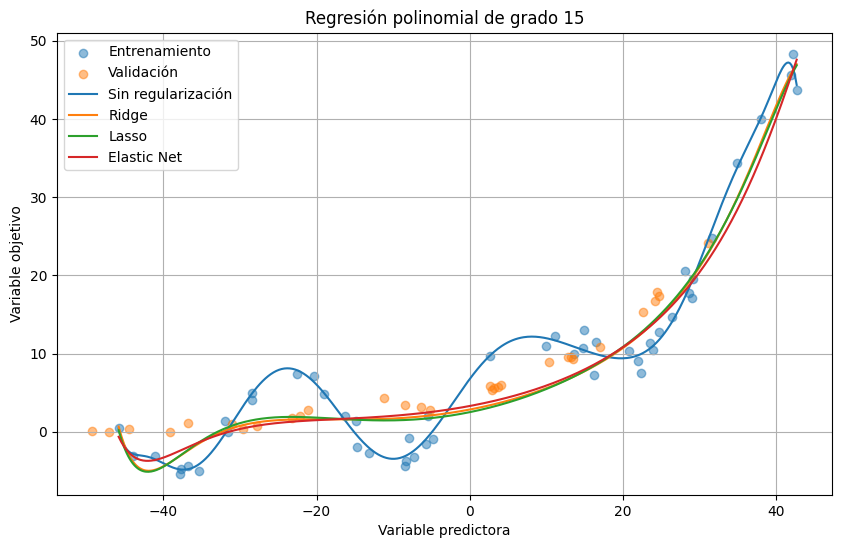

In [64]:
plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, alpha=0.5, label="Entrenamiento")
plt.scatter(X_val, y_val, alpha=0.5, label="Validación")

for nombre, resultado in resultados_grado15.items():

    pred = resultado["modelo"].predict(x_grafico)

    plt.plot(
        x_grafico,
        pred,
        label=nombre)

plt.xlabel("Variable predictora")
plt.ylabel("Variable objetivo")
plt.title("Regresión polinomial de grado 15")
plt.legend()
plt.grid()
plt.show()

Podemos observar como la curva sin regulación oscila mucho, lo que indica que el modelo posee una gran flexibilidad.

Al revisar los datos de la variable sin regulación, vemos unos valores de: MSE_train: 1.5737 | MSE_val: 256.3906.
Es enorme la diferencia, lo que indica una señal muy fuerte de sobreajuste.

Por lo tanto, el modelo consiguió ajustarse extraordinariamente bien a los datos que utilizó para entrenarse, pero cuando recibió datos que no había visto, cometió errores mucho mayores.

Lo más importante es que Elastic Net es claramente el mejor para grado 15, porque aunque tiene el MSE de entrenamiento más alto de los cuatro, tiene por lejos el menor MSE de validación.

Esto demuestra que no buscamos minimizar solamente el error de entrenamiento, sino obtener un modelo que generalice bien a datos que no vio.

## 5.6 Efecto de la intensidad de regularización

La regularización también introduce un nuevo problema de selección: ¿cuánto regularizar?


### Actividad 7

Mantenga fijo un grado polinomial alto (15) y evalúe distintos valores de `alpha` para Ridge. Compare MSE de entrenamiento y validación en función de `alpha`.

A partir de las curvas obtenidas, identifique qué valores de alpha producen subajuste y cuál ofrece el mejor compromiso entre error de entrenamiento y validación. Justifique a partir de los resultados.

In [65]:
grado = 15
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

resultados_ridge = []

for alpha in alphas:

    modelo = Pipeline([
        ("polinomio", PolynomialFeatures(degree=15)),
        ("escalado", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))])

    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val = modelo.predict(X_val)

    mse_train = mean_squared_error(y_train, pred_train)
    mse_val = mean_squared_error(y_val, pred_val)

    resultados_ridge.append({
        "alpha": alpha,
        "MSE_train": mse_train,
        "MSE_val": mse_val})

resultados_ridge_df = pd.DataFrame(resultados_ridge)

resultados_ridge_df

,alpha,MSE_train,MSE_val
0,0.001,3.309298,64.624532
1,0.010,5.371060,11.011271
2,0.100,8.776583,56.790132
3,1.000,11.311608,33.981843
4,10.000,14.898452,5.998714
5,100.000,39.560944,15.776024
6,1000.000,127.703298,31.673329


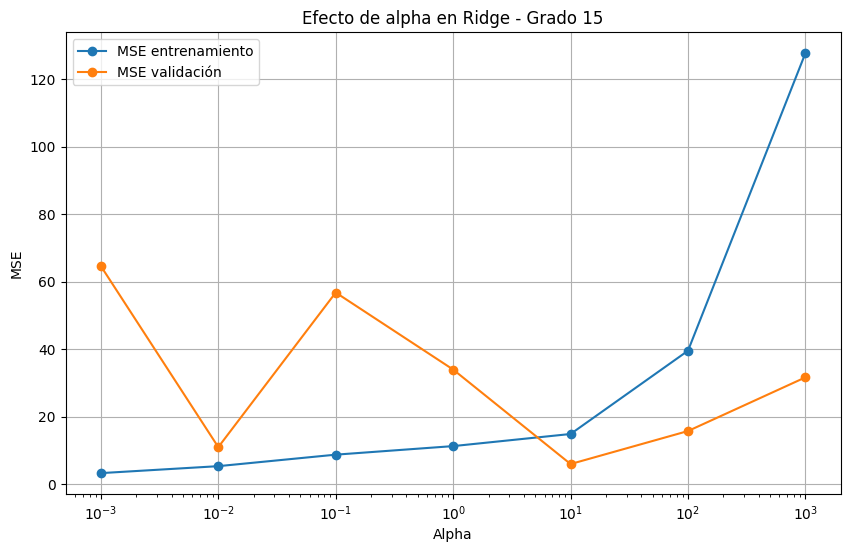

In [66]:
#Gráficos pedidos en la actividad
plt.figure(figsize=(10, 6))

plt.plot(
    resultados_ridge_df["alpha"],
    resultados_ridge_df["MSE_train"],
    marker="o",
    label="MSE entrenamiento")

plt.plot(
    resultados_ridge_df["alpha"],
    resultados_ridge_df["MSE_val"],
    marker="o",
    label="MSE validación")

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("MSE")
plt.title("Efecto de alpha en Ridge - Grado 15")
plt.legend()
plt.grid()
plt.show()

In [67]:
#Mejor alpha
mejor_ridge = resultados_ridge_df.loc[
    resultados_ridge_df["MSE_val"].idxmin()]

print("Mejor alpha:")
print(mejor_ridge)

Mejor alpha:
alpha        10.000000
MSE_train    14.898452
MSE_val       5.998714
Name: 4, dtype: float64


Con estos resultados vemos que se mantuvo fijo el grado polinomial en 15 y se evaluaron distintos valores de alpha para el modelo Ridge. Se observó que la intensidad de la regularización tiene un efecto importante sobre el equilibrio entre el error de entrenamiento y el de validación.

Para valores bajos de alpha, la regularización es débil y el modelo conserva una gran flexibilidad. Esto puede producir sobreajuste, caracterizado por un MSE de entrenamiento muy bajo y un MSE de validación elevado. Por el contrario, valores excesivamente altos de alpha pueden restringir demasiado el modelo y producir subajuste, aumentando tanto el error de entrenamiento como el de validación.

Entre los valores evaluados, el mejor resultado lo obtuvimos con alpha = 10, que presentó un MSE de entrenamiento de 14.898452 y un MSE de validación de 5.998714. Por lo tanto, este valor ofrece el mejor compromiso entre la capacidad de ajuste y la generalización sobre los datos de validación.

Además, al comparar este resultado con el polinomio de grado 15 sin regularización, se observa una mejora considerable. Sin regularización se obtuvo un MSE de entrenamiento de 1.5737 y un MSE de validación de 256.3906, mientras que Ridge con alpha = 10 obtuvo un MSE de validación de 5.998714. Esto evidencia cómo una regularización adecuada puede reducir significativamente el sobreajuste.